#### Run the `MaxFuse` integration on Xenium adult healthy colon data add-on dataset (425 probes) and adult healthy colon scRNA-seq to predict unmeasured genes on Xenium
- **Developed by:** Anna Maguza
- **Affilation:** Faculty of Medicine, Würzburg University
- **Created date:** 26th March 2025
- **Last modified dte:** 7th April 2025

In [ ]:
import numpy as np
import pandas as pd
from scipy.io import mmread
import scipy
import scipy.sparse

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (6, 4)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import anndata as ad
import scanpy as sc
import maxfuse as mf

import seaborn as sns

import pickle

from datetime import datetime
from tqdm import tqdm
import gc

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/sin

In [2]:
now = datetime.now()
timestamp = now.strftime("%d%m%Y_%H%M%S")

## Upload data

In [ ]:
spatial_adata = sc.read_h5ad('data/gut_data/gut_hs_XeniumAdultColonNicheCompass_AM_21102024_150114_raw.h5ad')

In [ ]:
rna_adata = sc.read_h5ad('data/gut_data/Healthy_colon_adult.h5ad')

In [5]:
shared_genes = list(set(spatial_adata.var_names).intersection(set(rna_adata.var_names)))
print(f"Number of shared genes: {len(shared_genes)}")

Number of shared genes: 407


In [6]:
spatial_shared = spatial_adata[:, shared_genes].copy()
rna_shared = rna_adata[:, shared_genes].copy()

In [7]:
if scipy.sparse.issparse(spatial_shared.X):
    spatial_var = spatial_shared.X.toarray().std(axis=0)
else:
    spatial_var = spatial_shared.X.std(axis=0)
    
if scipy.sparse.issparse(rna_shared.X):
    rna_var = rna_shared.X.toarray().std(axis=0)
else:
    rna_var = rna_shared.X.std(axis=0)

In [8]:
mask = (spatial_var > 0.1) & (rna_var > 0.5)
spatial_shared = spatial_shared[:, mask].copy()
rna_shared = rna_shared[:, mask].copy()
print(f"Number of variable shared genes: {sum(mask)}")

Number of variable shared genes: 188


## Preprocess shared objects

In [9]:
sc.pp.normalize_total(rna_shared, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(rna_shared)
sc.pp.scale(rna_shared)

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


In [10]:
rna_shared

AnnData object with n_obs × n_vars = 207754 × 188
    obs: 'Sample_ID', 'Cell_Type', 'Study_name', 'Donor_ID', 'Diagnosis', 'Age', 'Region code', 'Fraction', 'Sex', 'Library_Preparation_Protocol', 'batch', 'Age_group', 'Location', 'Cell States', 'Cell States GCA', 'Chem', 'Layer', 'Cell States Kong', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'pct_counts_ribo', 'Cell_ID', '_scvi_batch', '_scvi_labels', 'C_scANVI', 'seed_labels'
    var: 'gene_id-query', 'gene_name-query', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mito', 'ribo', 'mean', 'std'
    uns: 'Cell Type_colors', 'Donor_ID_colors', 'Study_name_colors', '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'neighbors', 'umap', 'log1p'
    obsm: 'X_scANVI', 'X_scvi', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs'
    obsp: 'connectivities', 'distances'

         Falling back to preprocessing with `sc.pp.pca` and default params.


/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/plot

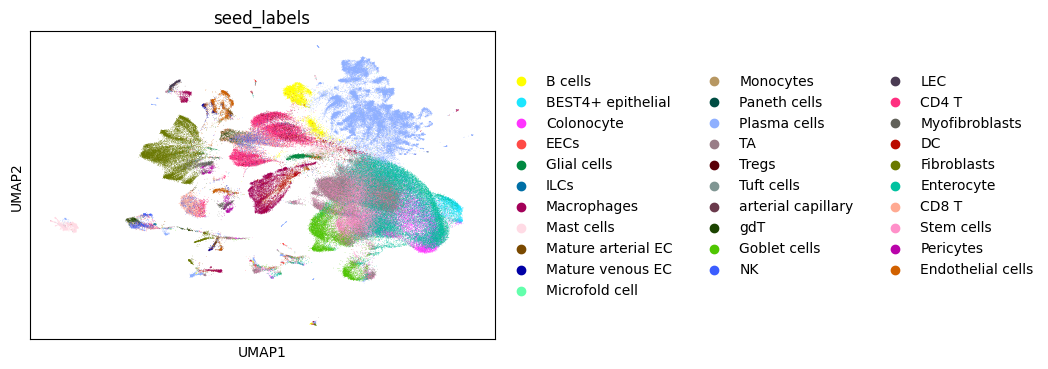

In [11]:
sc.pp.neighbors(rna_shared, n_neighbors=50)
sc.tl.umap(rna_shared)
sc.pl.umap(rna_shared, color='seed_labels')

In [10]:
sc.pp.normalize_total(spatial_shared)
sc.pp.log1p(spatial_shared)
sc.pp.scale(spatial_shared)

         Falling back to preprocessing with `sc.pp.pca` and default params.


/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Paramete

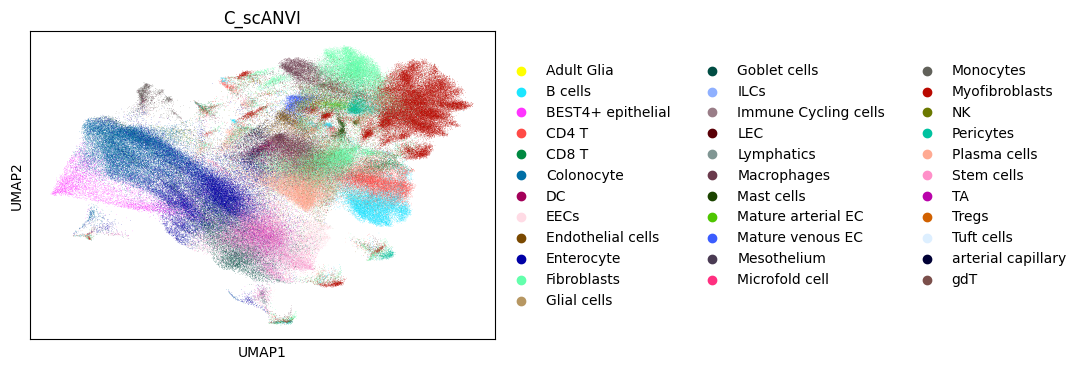

In [13]:
sc.pp.neighbors(spatial_shared, n_neighbors=50)
sc.tl.umap(spatial_shared)
sc.pl.umap(spatial_shared, color='C_scANVI')

In [11]:
rna_shared = rna_shared.X.copy()
spatial_shared = spatial_shared.X.copy()

## Preprocess full objects

In [12]:
sc.pp.normalize_total(rna_adata, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(rna_adata)
sc.pp.highly_variable_genes(rna_adata, n_top_genes=10000)
rna_adata = rna_adata[:, rna_adata.var.highly_variable].copy()
sc.pp.scale(rna_adata)

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]


         Falling back to preprocessing with `sc.pp.pca` and default params.


/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Paramete

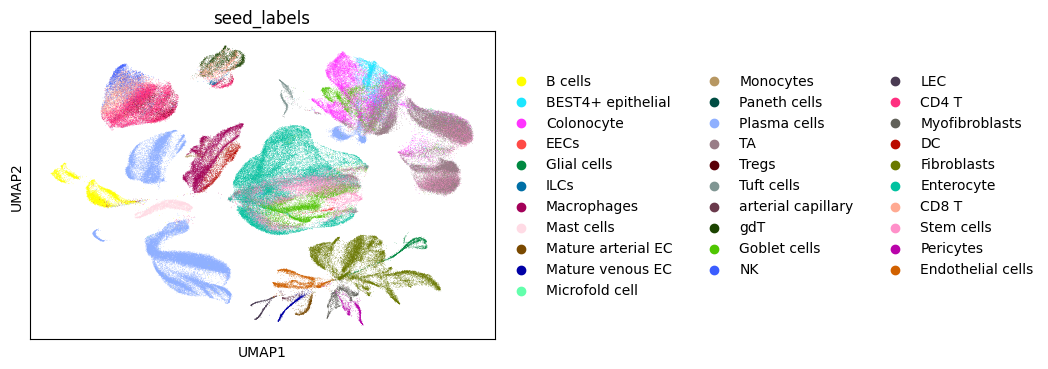

In [16]:
sc.pp.neighbors(rna_adata, n_neighbors=50)
sc.tl.umap(rna_adata)
sc.pl.umap(rna_adata, color='seed_labels')

In [4]:
sc.pp.normalize_total(spatial_adata)
sc.pp.log1p(spatial_adata)
sc.pp.scale(spatial_adata)

         Falling back to preprocessing with `sc.pp.pca` and default params.


/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Paramete

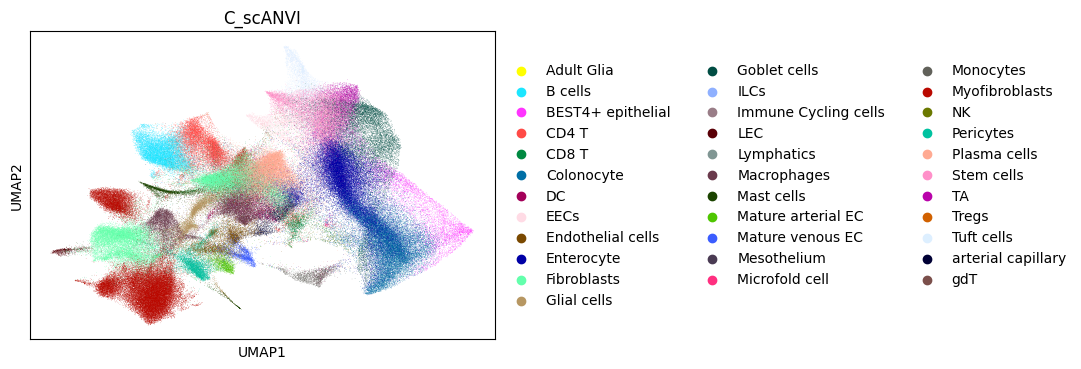

In [18]:
sc.pp.neighbors(spatial_adata, n_neighbors=50)
sc.tl.umap(spatial_adata)
sc.pl.umap(spatial_adata, color='C_scANVI')

+ make sure no feature is static

In [14]:
rna_active = rna_adata.X
spatial_active = spatial_adata.X
rna_active = rna_active[:, rna_active.std(axis=0) > 1e-5] # these are fine since already using variable features
spatial_active = spatial_active[:, spatial_active.std(axis=0) > 1e-5] # protein are generally variable

In [15]:
# inspect shape of the four matrices
print(rna_active.shape)
print(spatial_active.shape)
print(rna_shared.shape)
print(spatial_shared.shape)

(207754, 10000)
(274037, 425)
(207754, 188)
(274037, 188)


## Fitting MaxFuse

### Step I: preparations

In [20]:
rna_labels = rna_adata.obs['seed_labels'].to_numpy() if 'seed_labels' in rna_adata.obs else None
spatial_labels = spatial_adata.obs['C_scANVI'].to_numpy() if 'C_scANVI' in spatial_adata.obs else None

In [21]:
fusor = mf.model.Fusor(
    shared_arr1=rna_shared,
    shared_arr2=spatial_shared,
    active_arr1=rna_active,
    active_arr2=spatial_active,
    labels1=rna_labels,
    labels2=spatial_labels
)

In [22]:
fusor.split_into_batches(
    max_outward_size=8000,
    matching_ratio=4,
    metacell_size=2,
    verbose=True
)

The first data is split into 12 batches, average batch size is 17312, and max batch size is 17322.
The second data is split into 8 batches, average batch size is 34254, and max batch size is 34259.
Batch to batch correspondence is:
  ['0<->0', '0<->1', '0<->2', '0<->3', '0<->4', '0<->5', '0<->6', '0<->7', '1<->0', '1<->1', '1<->2', '1<->3', '1<->4', '1<->5', '1<->6', '1<->7', '2<->0', '2<->1', '2<->2', '2<->3', '2<->4', '2<->5', '2<->6', '2<->7', '3<->0', '3<->1', '3<->2', '3<->3', '3<->4', '3<->5', '3<->6', '3<->7', '4<->0', '4<->1', '4<->2', '4<->3', '4<->4', '4<->5', '4<->6', '4<->7', '5<->0', '5<->1', '5<->2', '5<->3', '5<->4', '5<->5', '5<->6', '5<->7', '6<->0', '6<->1', '6<->2', '6<->3', '6<->4', '6<->5', '6<->6', '6<->7', '7<->0', '7<->1', '7<->2', '7<->3', '7<->4', '7<->5', '7<->6', '7<->7', '8<->0', '8<->1', '8<->2', '8<->3', '8<->4', '8<->5', '8<->6', '8<->7', '9<->0', '9<->1', '9<->2', '9<->3', '9<->4', '9<->5', '9<->6', '9<->7', '10<->0', '10<->1', '10<->2', '10<->3', '10<-

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Singular value v.s. component index for batch 5'}, xlabel='Index', ylabel='Singular value'>)

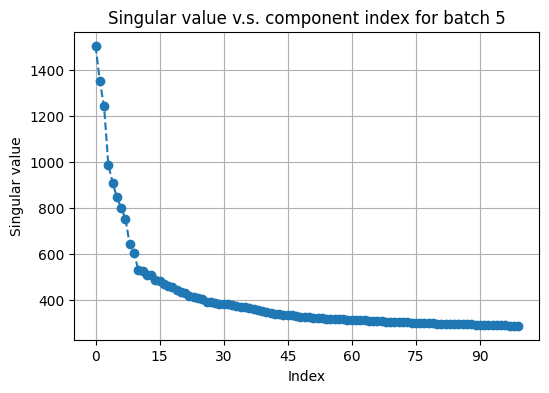

In [23]:
# plot top singular values of avtive_arr1 on a random batch
fusor.plot_singular_values(
    target='active_arr1',
    n_components=None # can also explicitly specify the number of components
)

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Singular value v.s. component index for batch 4'}, xlabel='Index', ylabel='Singular value'>)

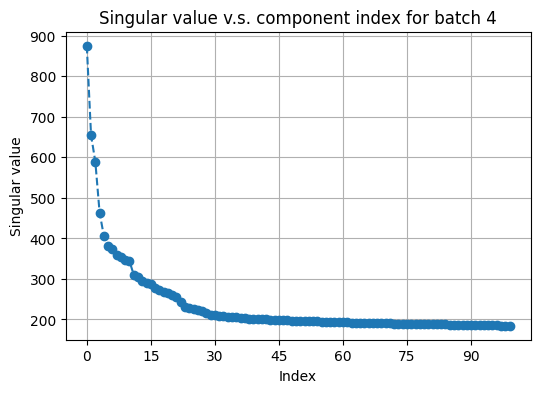

In [24]:
# plot top singular values of avtive_arr2 on a random batch
fusor.plot_singular_values(
    target='active_arr2',
    n_components=None
)

In [25]:
fusor.construct_graphs(
    n_neighbors1=30,  
    n_neighbors2=30,  
    svd_components1=50,  
    svd_components2=30,  
    resolution1=2,  
    resolution2=2,  
    resolution_tol=0.1,  
    verbose=True
)

Aggregating cells in arr1 into metacells of average size 2...
Constructing neighborhood graphs for cells in arr1...
Now at batch 0...


/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Now at batch 1...


/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Now at batch 2...


...

Now at batch 10...


/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Now at batch 11...


/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Graph construction finished!
Clustering into metacells...
Now at batch 0...
Metacell clustering finished!
Now at batch 1...
Metacell clustering finished!
Now at batch 2...
Metacell clustering finished!
Now at batch 3...
Metacell clustering finished!
Now at batch 4...
Metacell clustering finished!
Now at batch 5...
Metacell clustering finished!
Now at batch 6...
Metacell clustering finished!
Now at batch 7...
Metacell clustering finished!
Now at batch 8...
Metacell clustering finished!
Now at batch 9...
Metacell clustering finished!
Now at batch 10...
Metacell clustering finished!
Now at batch 11...
Metacell clustering finished!


### Step II: finding initial pivots

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Singular value v.s. component index for batch 2'}, xlabel='Index', ylabel='Singular value'>)

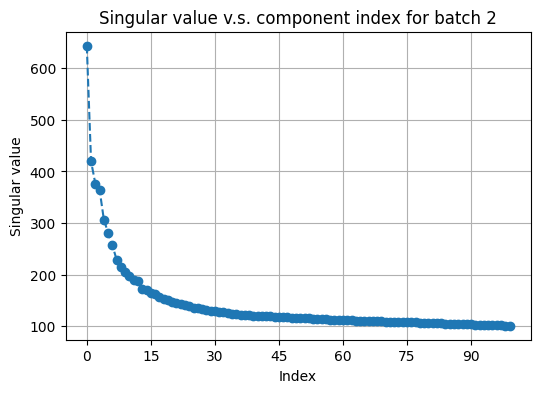

In [26]:
fusor.plot_singular_values(
    target='shared_arr1',
    n_components=None,
)

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Singular value v.s. component index for batch 4'}, xlabel='Index', ylabel='Singular value'>)

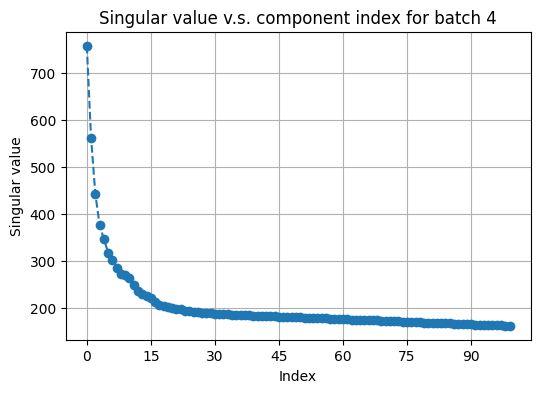

In [27]:
fusor.plot_singular_values(
    target='shared_arr2',
    n_components=None
)

Saving any variable to disk

In [ ]:
# Save the object to disk
with open(f"data/gut_data/MaxFuse_fusor_constructed_graph_{timestamp}.pkl", 'wb') as file:
    pickle.dump(fusor, file)

In [ ]:
# Later, load the object from disk
with open('/home/nkise/Documents/Anya/notebooks/fusor.pkl', 'rb') as file:
    fusor = pickle.load(file)

----------------------------

In [35]:
fusor.find_initial_pivots(
    wt1=0.4, wt2=0.3,
    svd_components1=25, svd_components2=20
)

Now at batch 0<->0...


Now at batch 0<->1...
Now at batch 0<->2...
Now at batch 0<->3...
Now at batch 0<->4...
Now at batch 0<->5...
Now at batch 0<->6...
Now at batch 0<->7...
Now at batch 1<->0...
Now at batch 1<->1...
Now at batch 1<->2...
Now at batch 1<->3...
Now at batch 1<->4...
Now at batch 1<->5...
Now at batch 1<->6...
Now at batch 1<->7...
Now at batch 2<->0...
Now at batch 2<->1...
Now at batch 2<->2...
Now at batch 2<->3...
Now at batch 2<->4...
Now at batch 2<->5...
Now at batch 2<->6...
Now at batch 2<->7...
Now at batch 3<->0...
Now at batch 3<->1...
Now at batch 3<->2...
Now at batch 3<->3...
Now at batch 3<->4...
Now at batch 3<->5...
Now at batch 3<->6...
Now at batch 3<->7...
Now at batch 4<->0...
Now at batch 4<->1...
Now at batch 4<->2...
Now at batch 4<->3...
Now at batch 4<->4...
Now at batch 4<->5...
Now at batch 4<->6...
Now at batch 4<->7...
Now at batch 5<->0...
Now at batch 5<->1...
Now at batch 5<->2...
Now at batch 5<->3...
Now at batch 5<->4...
Now at batch 5<->5...
Now at bat

## Step III: finding refined pivots

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Canonical correlation v.s. component index for batch 2<->1'}, xlabel='Index', ylabel='Canonical correlation'>)

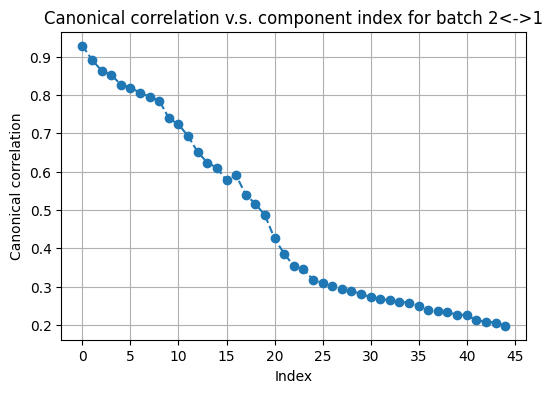

In [36]:
fusor.plot_canonical_correlations(
    svd_components1=50,
    svd_components2=None,
    cca_components=45
)

In [38]:
fusor.refine_pivots(
    wt1=0.3, wt2=0.3,
    svd_components1=40, svd_components2=None,
    cca_components=15,
    n_iters=1,
    randomized_svd=False, 
    svd_runs=1,
    verbose=True
)

Now at batch 0<->0...
Now at batch 0<->1...
Now at batch 0<->2...
Now at batch 0<->3...
Now at batch 0<->4...
Now at batch 0<->5...
Now at batch 0<->6...
Now at batch 0<->7...
Now at batch 1<->0...
Now at batch 1<->1...
Now at batch 1<->2...
Now at batch 1<->3...
Now at batch 1<->4...
Now at batch 1<->5...
Now at batch 1<->6...
Now at batch 1<->7...
Now at batch 2<->0...
Now at batch 2<->1...
Now at batch 2<->2...
Now at batch 2<->3...
Now at batch 2<->4...
Now at batch 2<->5...
Now at batch 2<->6...
Now at batch 2<->7...
Now at batch 3<->0...
Now at batch 3<->1...
Now at batch 3<->2...
Now at batch 3<->3...
Now at batch 3<->4...
Now at batch 3<->5...
Now at batch 3<->6...
Now at batch 3<->7...
Now at batch 4<->0...
Now at batch 4<->1...
Now at batch 4<->2...
Now at batch 4<->3...
Now at batch 4<->4...
Now at batch 4<->5...
Now at batch 4<->6...
Now at batch 4<->7...
Now at batch 5<->0...
Now at batch 5<->1...
Now at batch 5<->2...
Now at batch 5<->3...
Now at batch 5<->4...
Now at bat

In [39]:
fusor.filter_bad_matches(target='pivot', filter_prop=0.5)

Begin filtering...
Now at batch 0<->0...
Now at batch 0<->1...
Now at batch 0<->2...
Now at batch 0<->3...
Now at batch 0<->4...
Now at batch 0<->5...
Now at batch 0<->6...
Now at batch 0<->7...
Now at batch 1<->0...
Now at batch 1<->1...
Now at batch 1<->2...
Now at batch 1<->3...
Now at batch 1<->4...
Now at batch 1<->5...
Now at batch 1<->6...
Now at batch 1<->7...
Now at batch 2<->0...
Now at batch 2<->1...
Now at batch 2<->2...
Now at batch 2<->3...
Now at batch 2<->4...
Now at batch 2<->5...
Now at batch 2<->6...
Now at batch 2<->7...
Now at batch 3<->0...
Now at batch 3<->1...
Now at batch 3<->2...
Now at batch 3<->3...
Now at batch 3<->4...
Now at batch 3<->5...
Now at batch 3<->6...
Now at batch 3<->7...
Now at batch 4<->0...
Now at batch 4<->1...
Now at batch 4<->2...
Now at batch 4<->3...
Now at batch 4<->4...
Now at batch 4<->5...
Now at batch 4<->6...
Now at batch 4<->7...
Now at batch 5<->0...
Now at batch 5<->1...
Now at batch 5<->2...
Now at batch 5<->3...
Now at batch 

In [40]:
pivot_matching = fusor.get_matching(order=None,target='pivot')

lv1_acc = mf.metrics.get_matching_acc(matching=pivot_matching, 
    labels1=rna_labels, 
    labels2=spatial_labels,
    order = None
)
lv1_acc

0.7662437817369114

In [41]:
[pivot_matching[0][0], pivot_matching[1][0], pivot_matching[2][0]]

[56331, 5, 0.9375216444364961]

In [ ]:
cm = confusion_matrix(rna_labels[pivot_matching[0]], spatial_labels[pivot_matching[1]])
ConfusionMatrixDisplay(
    confusion_matrix=np.round((cm.T/np.sum(cm, axis=1)).T*100), 
    display_labels=np.unique(rna_labels)
).plot()

## Propagate

In [42]:
fusor.propagate(
    svd_components1=40, 
    svd_components2=None, 
    wt1=0.4,
    wt2=0.3,
)

Now at batch 0<->0...
Now at batch 0<->1...
Now at batch 0<->2...
Now at batch 0<->3...
Now at batch 0<->4...
Now at batch 0<->5...
Now at batch 0<->6...
Now at batch 0<->7...
Now at batch 1<->0...
Now at batch 1<->1...
Now at batch 1<->2...
Now at batch 1<->3...
Now at batch 1<->4...
Now at batch 1<->5...
Now at batch 1<->6...
Now at batch 1<->7...
Now at batch 2<->0...
Now at batch 2<->1...
Now at batch 2<->2...
Now at batch 2<->3...
Now at batch 2<->4...
Now at batch 2<->5...
Now at batch 2<->6...
Now at batch 2<->7...
Now at batch 3<->0...
Now at batch 3<->1...
Now at batch 3<->2...
Now at batch 3<->3...
Now at batch 3<->4...
Now at batch 3<->5...
Now at batch 3<->6...
Now at batch 3<->7...
Now at batch 4<->0...
Now at batch 4<->1...
Now at batch 4<->2...
Now at batch 4<->3...
Now at batch 4<->4...
Now at batch 4<->5...
Now at batch 4<->6...
Now at batch 4<->7...
Now at batch 5<->0...
Now at batch 5<->1...
Now at batch 5<->2...
Now at batch 5<->3...
Now at batch 5<->4...
Now at bat

In [43]:
fusor.filter_bad_matches(
    target='propagated',
    filter_prop=0.5
)


Begin filtering...
Now at batch 0<->0...
Now at batch 0<->1...
Now at batch 0<->2...
Now at batch 0<->3...
Now at batch 0<->4...
Now at batch 0<->5...
Now at batch 0<->6...
Now at batch 0<->7...
Now at batch 1<->0...
Now at batch 1<->1...
Now at batch 1<->2...
Now at batch 1<->3...
Now at batch 1<->4...
Now at batch 1<->5...
Now at batch 1<->6...
Now at batch 1<->7...
Now at batch 2<->0...
Now at batch 2<->1...
Now at batch 2<->2...
Now at batch 2<->3...
Now at batch 2<->4...
Now at batch 2<->5...
Now at batch 2<->6...
Now at batch 2<->7...
Now at batch 3<->0...
Now at batch 3<->1...
Now at batch 3<->2...
Now at batch 3<->3...
Now at batch 3<->4...
Now at batch 3<->5...
Now at batch 3<->6...
Now at batch 3<->7...
Now at batch 4<->0...
Now at batch 4<->1...
Now at batch 4<->2...
Now at batch 4<->3...
Now at batch 4<->4...
Now at batch 4<->5...
Now at batch 4<->6...
Now at batch 4<->7...
Now at batch 5<->0...
Now at batch 5<->1...
Now at batch 5<->2...
Now at batch 5<->3...
Now at batch 

In [44]:
full_matching = fusor.get_matching(order=None, target='full_data')

In [45]:
match_df = pd.DataFrame(list(zip(full_matching[0], full_matching[1], full_matching[2])), 
             columns = ['mod1_indx', 'mod2_indx', 'score'])

In [46]:
lv1_acc = mf.metrics.get_matching_acc(matching=full_matching, 
    labels1=rna_labels, 
    labels2=spatial_labels 
)
lv1_acc

0.666132688064839

In [ ]:
match_df.to_csv('data/gut_data/MaxFuse_results.csv')

In [ ]:
# Save the object to disk
with open('data/gut_data/MaxFuse_fusor_propagated_{timestamp}.pkl', 'wb') as file:
    pickle.dump(fusor, file)

## Step V: downstream analysis

In [49]:
rna_cca, spatial_cca_sub = fusor.get_embedding(
    active_arr1=fusor.active_arr1,
    active_arr2=fusor.active_arr2[full_matching[1],:] # cells in codex remained after filtering
)

In [50]:
np.random.seed(42)
subs = 13000
randix = np.random.choice(spatial_cca_sub.shape[0],subs, replace = False)

dim_use = 15 # dimensions of the CCA embedding to be used for UMAP etc

cca_adata = ad.AnnData(
    np.concatenate((rna_cca[:,:dim_use], spatial_cca_sub[randix,:dim_use]), axis=0), 
    dtype=np.float32
)
cca_adata.obs['data_type'] = ['rna'] * rna_cca.shape[0] + ['spatial'] * subs
cca_adata.obs['cell_type'] = list(np.concatenate((rna_labels,
                                                  spatial_labels[full_matching[1]][randix]), axis = 0))

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


In [54]:
sc.pp.neighbors(cca_adata, n_neighbors=50)
sc.tl.umap(cca_adata)

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'igno

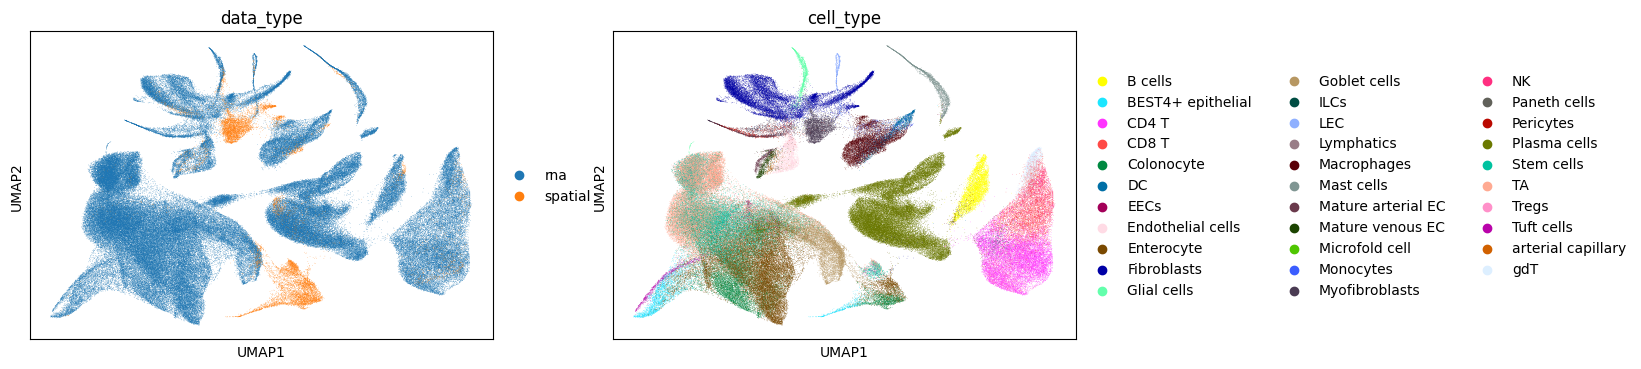

In [55]:
sc.pl.umap(cca_adata, color=['data_type','cell_type'])

In [ ]:
cca_adata.write_h5ad('data/gut_data/maxfuse_integrated_cca.h5ad')
cca_adata

AnnData object with n_obs × n_vars = 220754 × 15
    obs: 'data_type', 'cell_type'
    uns: 'neighbors', 'umap', 'data_type_colors', 'cell_type_colors'
    obsm: 'X_umap'
    obsp: 'distances', 'connectivities'

## Transfer imputed genes

In [ ]:
match_df = pd.read_csv('data/gut_data/MaxFuse_results.csv')
match_df

,Unnamed: 0,mod1_indx,mod2_indx,score
0,0,56331,5,0.937522
1,1,17233,5,0.813167
2,2,89190,15,0.926714
3,3,88416,15,0.907489
4,4,88480,15,0.907285
...,...,...,...,...
3382153,3382153,15299,274036,0.742010
3382154,3382154,47658,274036,0.708229
3382155,3382155,116098,274036,0.695431
3382156,3382156,48745,274036,0.512770


In [8]:
rna_only_genes = list(set(rna_adata.var_names).difference(set(spatial_adata.var_names)))

In [10]:
del rna_adata

In [9]:
best_matches = match_df.loc[match_df.groupby('mod2_indx')['score'].idxmax()]

In [ ]:
# Using smaller batch size for better progress tracking
batch_size = 1000  # Reduced from 1000 to 100

# Create a dictionary to store transferred data
transferred_data = {}

# Count total number of cells in best_matches for progress bar
total_matches = len(best_matches)
print(f"Processing {total_matches} cell matches across {len(rna_only_genes)} genes")

# Process by gene batches
num_batches = (len(rna_only_genes) + batch_size - 1) // batch_size
for batch_idx in tqdm(range(num_batches), desc="Gene batches"):
    start_idx = batch_idx * batch_size
    end_idx = min(start_idx + batch_size, len(rna_only_genes))
    current_genes = rna_only_genes[start_idx:end_idx]
    
    # Create a sparse matrix for this batch
    transfer_matrix = scipy.sparse.lil_matrix((spatial_adata.n_obs, len(current_genes)))
    
    # Process each match with a nested progress bar
    for match_idx, row in tqdm(best_matches.iterrows(), 
                               desc=f"Batch {batch_idx+1}/{num_batches}",
                               total=total_matches,
                               leave=False):
        rna_idx = int(row['mod1_indx'])
        xenium_idx = int(row['mod2_indx'])
        
        # Get RNA expression for current genes
        try:
            expr = rna_adata[rna_idx, current_genes].X
            if scipy.sparse.issparse(expr):
                expr = expr.toarray()
            
            # Transfer to Xenium cell
            transfer_matrix[xenium_idx, :] = expr.flatten()
        except Exception as e:
            print(f"Error processing match {match_idx}, rna_idx={rna_idx}, xenium_idx={xenium_idx}: {e}")
            continue
    
    # Convert to CSR format for efficiency
    transfer_matrix = transfer_matrix.tocsr()
    
    # Store data for each gene
    for i, gene in enumerate(current_genes):
        transferred_data[gene] = transfer_matrix[:, i]
    
    # Clear some memory
    del transfer_matrix
    
    # Save checkpoint after each batch
    if (batch_idx + 1) % 5 == 0 or batch_idx == num_batches - 1:
        print(f"Saving checkpoint after batch {batch_idx+1}/{num_batches}")
        with open(f'data/gut_data/maxfuse_checkpoints/transferred_data_batch_{batch_idx+1}.pkl', 'wb') as f:
            pickle.dump(transferred_data, f)


Processing 197295 cell matches across 9865 genes


Gene batches:  40%|██████████████████████████████████████████████████████████████                                                                                             | 4/10 [41:36<1:02:06, 621.05s/it]

Saving checkpoint after batch 5/10


Gene batches:  90%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌               | 9/10 [1:36:38<10:48, 648.78s/it]

Saving checkpoint after batch 10/10


Gene batches: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [1:47:47<00:00, 646.78s/it]


In [ ]:
with open('data/gut_data/maxfuse_checkpoints/transferred_data_complete.pkl', 'wb') as f:
    pickle.dump(transferred_data, f)

In [ ]:
# Later, load the object from disk
with open('data/gut_data/maxfuse_checkpoints/transferred_data_complete.pkl', 'rb') as file:
    transferred_data = pickle.load(file)

In [ ]:
chunk_size = 20  
total_chunks = (len(rna_only_genes) + chunk_size - 1) // chunk_size

chunk_matrices = []
transferred_gene_names = []

# Process each chunk
for chunk_idx in tqdm(range(total_chunks), desc="Processing gene chunks"):
    start_idx = chunk_idx * chunk_size
    end_idx = min(start_idx + chunk_size, len(rna_only_genes))
    current_genes = rna_only_genes[start_idx:end_idx]
    
    # Create a matrix for this chunk
    chunk_matrix = scipy.sparse.lil_matrix((spatial_adata.n_obs, len(current_genes)))
    chunk_genes_added = []
    
    # Process each gene in this chunk
    for i, gene in enumerate(current_genes):
        if gene in transferred_data:
            chunk_matrix[:, i] = transferred_data[gene]
            chunk_genes_added.append(gene)
            
            # Remove from dictionary to free memory
            del transferred_data[gene]
    
    # Only keep the columns for genes that were successfully added
    if chunk_genes_added:
        # Keep track of which genes were successfully transferred
        transferred_gene_names.extend(chunk_genes_added)
        
        # Convert to CSR and keep the matrix
        if len(chunk_genes_added) == len(current_genes):
            # All genes were added, keep the full matrix
            chunk_matrices.append(chunk_matrix.tocsr())
        else:
            # Only some genes were added, extract just those columns
            indices = [i for i, gene in enumerate(current_genes) if gene in chunk_genes_added]
            reduced_matrix = chunk_matrix[:, indices].tocsr()
            chunk_matrices.append(reduced_matrix)
    
    # Clean up memory
    del chunk_matrix
    gc.collect()
    
    # Save progress periodically
    if (chunk_idx + 1) % 10 == 0 or chunk_idx == total_chunks - 1:
        print(f"Processed {chunk_idx+1}/{total_chunks} chunks, transferred {len(transferred_gene_names)} genes so far")

In [ ]:
if chunk_matrices:
    print(f"Combining matrices for {len(transferred_gene_names)} transferred genes...")
    if len(chunk_matrices) > 1:
        combined_matrix = scipy.sparse.hstack(chunk_matrices, format='csr')
    else:
        combined_matrix = chunk_matrices[0]
    
    transferred_adata = ad.AnnData(
        X=combined_matrix,
        obs=spatial_adata.obs.copy(),
        var=pd.DataFrame(index=transferred_gene_names)
    )

Processing gene chunks:   1%|██▌                                                                                                                                                                                                                                                                                                          | 10/1161 [00:08<17:15,  1.11it/s]

Processed 10/1161 chunks, transferred 75 genes so far


Processing gene chunks:   2%|█████▏                                                                                                                                                                                                                                                                                                       | 20/1161 [00:18<18:52,  1.01it/s]

Processed 20/1161 chunks, transferred 172 genes so far


Processing gene chunks:   3%|███████▊                                                                                                                                                                                                                                                                                                     | 30/1161 [00:29<23:34,  1.25s/it]

...

Processing gene chunks: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋| 1160/1161 [18:45<00:00,  1.02it/s]

Processed 1160/1161 chunks, transferred 9851 genes so far


Processing gene chunks: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1161/1161 [18:47<00:00,  1.03it/s]

Processed 1161/1161 chunks, transferred 9856 genes so far
Combining matrices for 9856 transferred genes...


Saving transferred genes AnnData...
Successfully transferred 9856 genes


In [ ]:
transferred_adata.obs['match_score'] = np.nan

In [ ]:
xenium_idx_to_score = best_matches.set_index('mod2_indx')['score'].to_dict()
for idx, score in tqdm(xenium_idx_to_score.items(), total=len(xenium_idx_to_score)):
    if idx < len(transferred_adata.obs):
        transferred_adata.obs.iloc[idx, transferred_adata.obs.columns.get_loc('match_score')] = score

In [ ]:
transferred_adata.uns['transferred_genes'] = transferred_gene_names
transferred_adata.uns['num_transferred_genes'] = len(transferred_gene_names)

In [34]:
matched_indices = transferred_adata.obs.index[~transferred_adata.obs['match_score'].isna()]
transferred_adata.obs['has_match'] = transferred_adata.obs.index.isin(matched_indices)

In [ ]:
transferred_adata.write(f"data/gut_data/maxfuse_checkpoints/gut_hs_XeniumHealthyColon_maxfuse_imputed_adata_{timestamp}.h5ad")

In [38]:
transferred_adata.obs['has_match'].value_counts()

has_match
True     197295
False     76742
Name: count, dtype: int64

In [32]:
transferred_adata.var

""
LINC00948
C20orf194
ATP1A3
DDR2
CTD-3162L10.1
...
BLOC1S4
RP3-402G11.27
RP11-227G15.8
INHBA-AS1
